# Bio RealNVP contours

Push forward Gaussian ball boundaries through the pretrained conditional RealNVP model.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
from matplotlib.ticker import LinearLocator
from scipy.stats import chi2

REPOSITORY_ROOT = next(
    path
    for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "src").is_dir()
)
sys.path.insert(0, str(REPOSITORY_ROOT / "src"))

from configs.calibrators import NormCalibratorConfig
from configs.conformal import TransportBasedConformalPredictorConfig
from configs.datasets.real import BioDatasetConfig
from configs.predictors.transport import NormalizingFlowPredictorConfig
from conformal import TransportBasedConformalPredictor
from data.datasets.real import BioDataset
from data.loaders import make_xy_dataloader
from predictors.rearranged_transport import AmortizedRearrangedTransport
from predictors.transport import NormalizingFlowPredictor

CHECKPOINT_PATH = REPOSITORY_ROOT / "benchmark/downloads/bio_seed_0/base/predictor.pt"
REARRANGEMENT_PATH = REPOSITORY_ROOT / "benchmark/downloads/bio_seed_0/rearrangement/predictor.pt"
RANDOM_SEED = 7
N_COVARIATES = 6
BOUNDARY_POINTS = 400
DENSITY_GRID_SIZE = 320

plt.rcParams.update({"figure.dpi": 120, "font.size": 15})

In [2]:
checkpoint = torch.load(CHECKPOINT_PATH, map_location="cpu", weights_only=False)
model_config = NormalizingFlowPredictorConfig.model_validate(
    {**checkpoint["config"], "device": "cpu"}
)
predictor = NormalizingFlowPredictor(model_config)
predictor.load_state_dict(checkpoint["state_dict"])
predictor.eval()
rearranged_predictor = AmortizedRearrangedTransport.load(
    REARRANGEMENT_PATH, map_location="cpu"
)
rearranged_predictor.eval()

dataset = BioDataset(
    BioDatasetConfig(seed=0, device="cpu", dtype="float32")
)
test_data = dataset.get_splits().test

In [3]:
def gaussian_ball_boundary(mass, n_points=BOUNDARY_POINTS):
    radius = np.sqrt(chi2.ppf(mass, df=2))
    angles = torch.linspace(0, 2 * torch.pi, n_points + 1)
    return radius * torch.stack((torch.cos(angles), torch.sin(angles)), dim=1)


@torch.inference_mode()
def pushforward_contour(model, x, mass):
    u = gaussian_ball_boundary(mass)
    x_batch = x.unsqueeze(0).expand(u.shape[0], -1)
    if isinstance(model, AmortizedRearrangedTransport):
        y = model.pushforward(x=x_batch, u=u, coverage_mass=mass)
    else:
        y = model.pushforward(x=x_batch, u=u)
    return y.cpu().numpy()


def padded_bounds(contours, padding=0.12):
    points = np.concatenate(contours, axis=0)
    lower = points.min(axis=0)
    upper = points.max(axis=0)
    margin = padding * (upper - lower)
    return lower - margin, upper + margin


@torch.inference_mode()
def density_grid(x, lower, upper, grid_size=DENSITY_GRID_SIZE):
    f7 = np.linspace(lower[0], upper[0], grid_size)
    f9 = np.linspace(lower[1], upper[1], grid_size)
    f7_grid, f9_grid = np.meshgrid(f7, f9)
    y_grid = torch.tensor(
        np.column_stack((f7_grid.ravel(), f9_grid.ravel())),
        dtype=torch.float32,
    )

    values = []
    for y_batch in y_grid.split(8192):
        x_batch = x.unsqueeze(0).expand(y_batch.shape[0], -1)
        values.append(predictor.log_prob(x=x_batch, y=y_batch).exp().cpu())

    density = torch.cat(values).reshape(grid_size, grid_size).numpy()
    return f7_grid, f9_grid, density


def hdr_thresholds(density, f7_grid, f9_grid, masses):
    cell_area = (f7_grid[0, 1] - f7_grid[0, 0]) * (f9_grid[1, 0] - f9_grid[0, 0])
    sorted_density = np.sort(density.ravel())[::-1]
    cumulative_mass = np.cumsum(sorted_density) * cell_area

    if cumulative_mass[-1] < max(masses):
        raise ValueError("The density grid is too small to estimate the requested HDR.")

    return {
        mass: sorted_density[np.searchsorted(cumulative_mass, mass)]
        for mass in masses
    }

## 50% Gaussian-ball pushforwards for test covariates

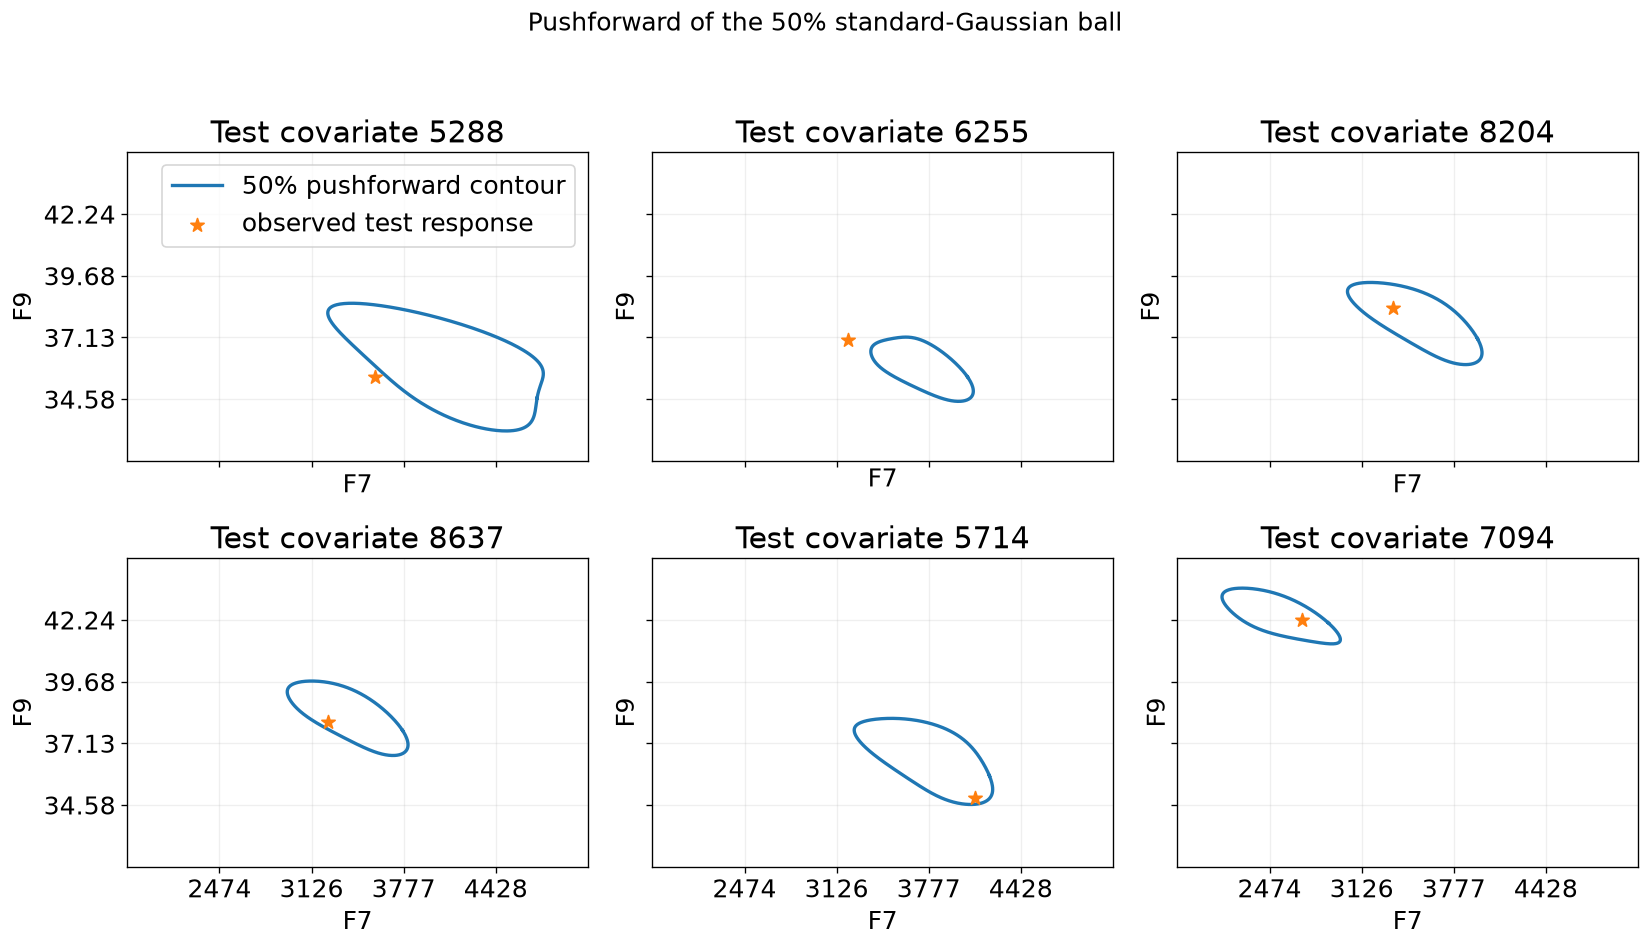

In [4]:
rng = np.random.default_rng(RANDOM_SEED)
test_indices = rng.choice(len(test_data.x), size=N_COVARIATES, replace=False)
contours_50 = [
    pushforward_contour(predictor, test_data.x[index], mass=0.50)
    for index in test_indices
]
lower, upper = padded_bounds(contours_50)

fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=True, sharey=True)
for axis, index, contour in zip(axes.flat, test_indices, contours_50):
    observed_y = test_data.y[index].cpu().numpy()
    axis.plot(contour[:, 0], contour[:, 1], color="tab:blue", linewidth=2)
    axis.scatter(*observed_y, color="tab:orange", marker="*", s=70, zorder=3)
    axis.set_title(f"Test covariate {index}")
    axis.set_xlabel("F7")
    axis.set_ylabel("F9")
    axis.set_xlim(lower[0], upper[0])
    axis.set_ylim(lower[1], upper[1])
    axis.xaxis.set_major_locator(LinearLocator(6))
    axis.yaxis.set_major_locator(LinearLocator(6))
    for axis_ticks in (axis.xaxis.get_major_ticks(), axis.yaxis.get_major_ticks()):
        for edge_tick in (axis_ticks[0], axis_ticks[-1]):
            edge_tick.tick1line.set_visible(False)
            edge_tick.tick2line.set_visible(False)
            edge_tick.label1.set_visible(False)
            edge_tick.label2.set_visible(False)
            edge_tick.gridline.set_visible(False)
    axis.grid(alpha=0.2)

fig.suptitle("Pushforward of the 50% standard-Gaussian ball", fontsize=15, y=0.99)
axes.flat[0].legend(
    ["50% pushforward contour", "observed test response"],
    loc="upper right",
)
fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

## Nested pushforward contours, learned density, and HDRs

The HDR threshold for mass $\alpha$ is estimated by sorting density-grid cells from highest to lowest density and accumulating $p(y\mid x)\,dy$ until the mass reaches $\alpha$.

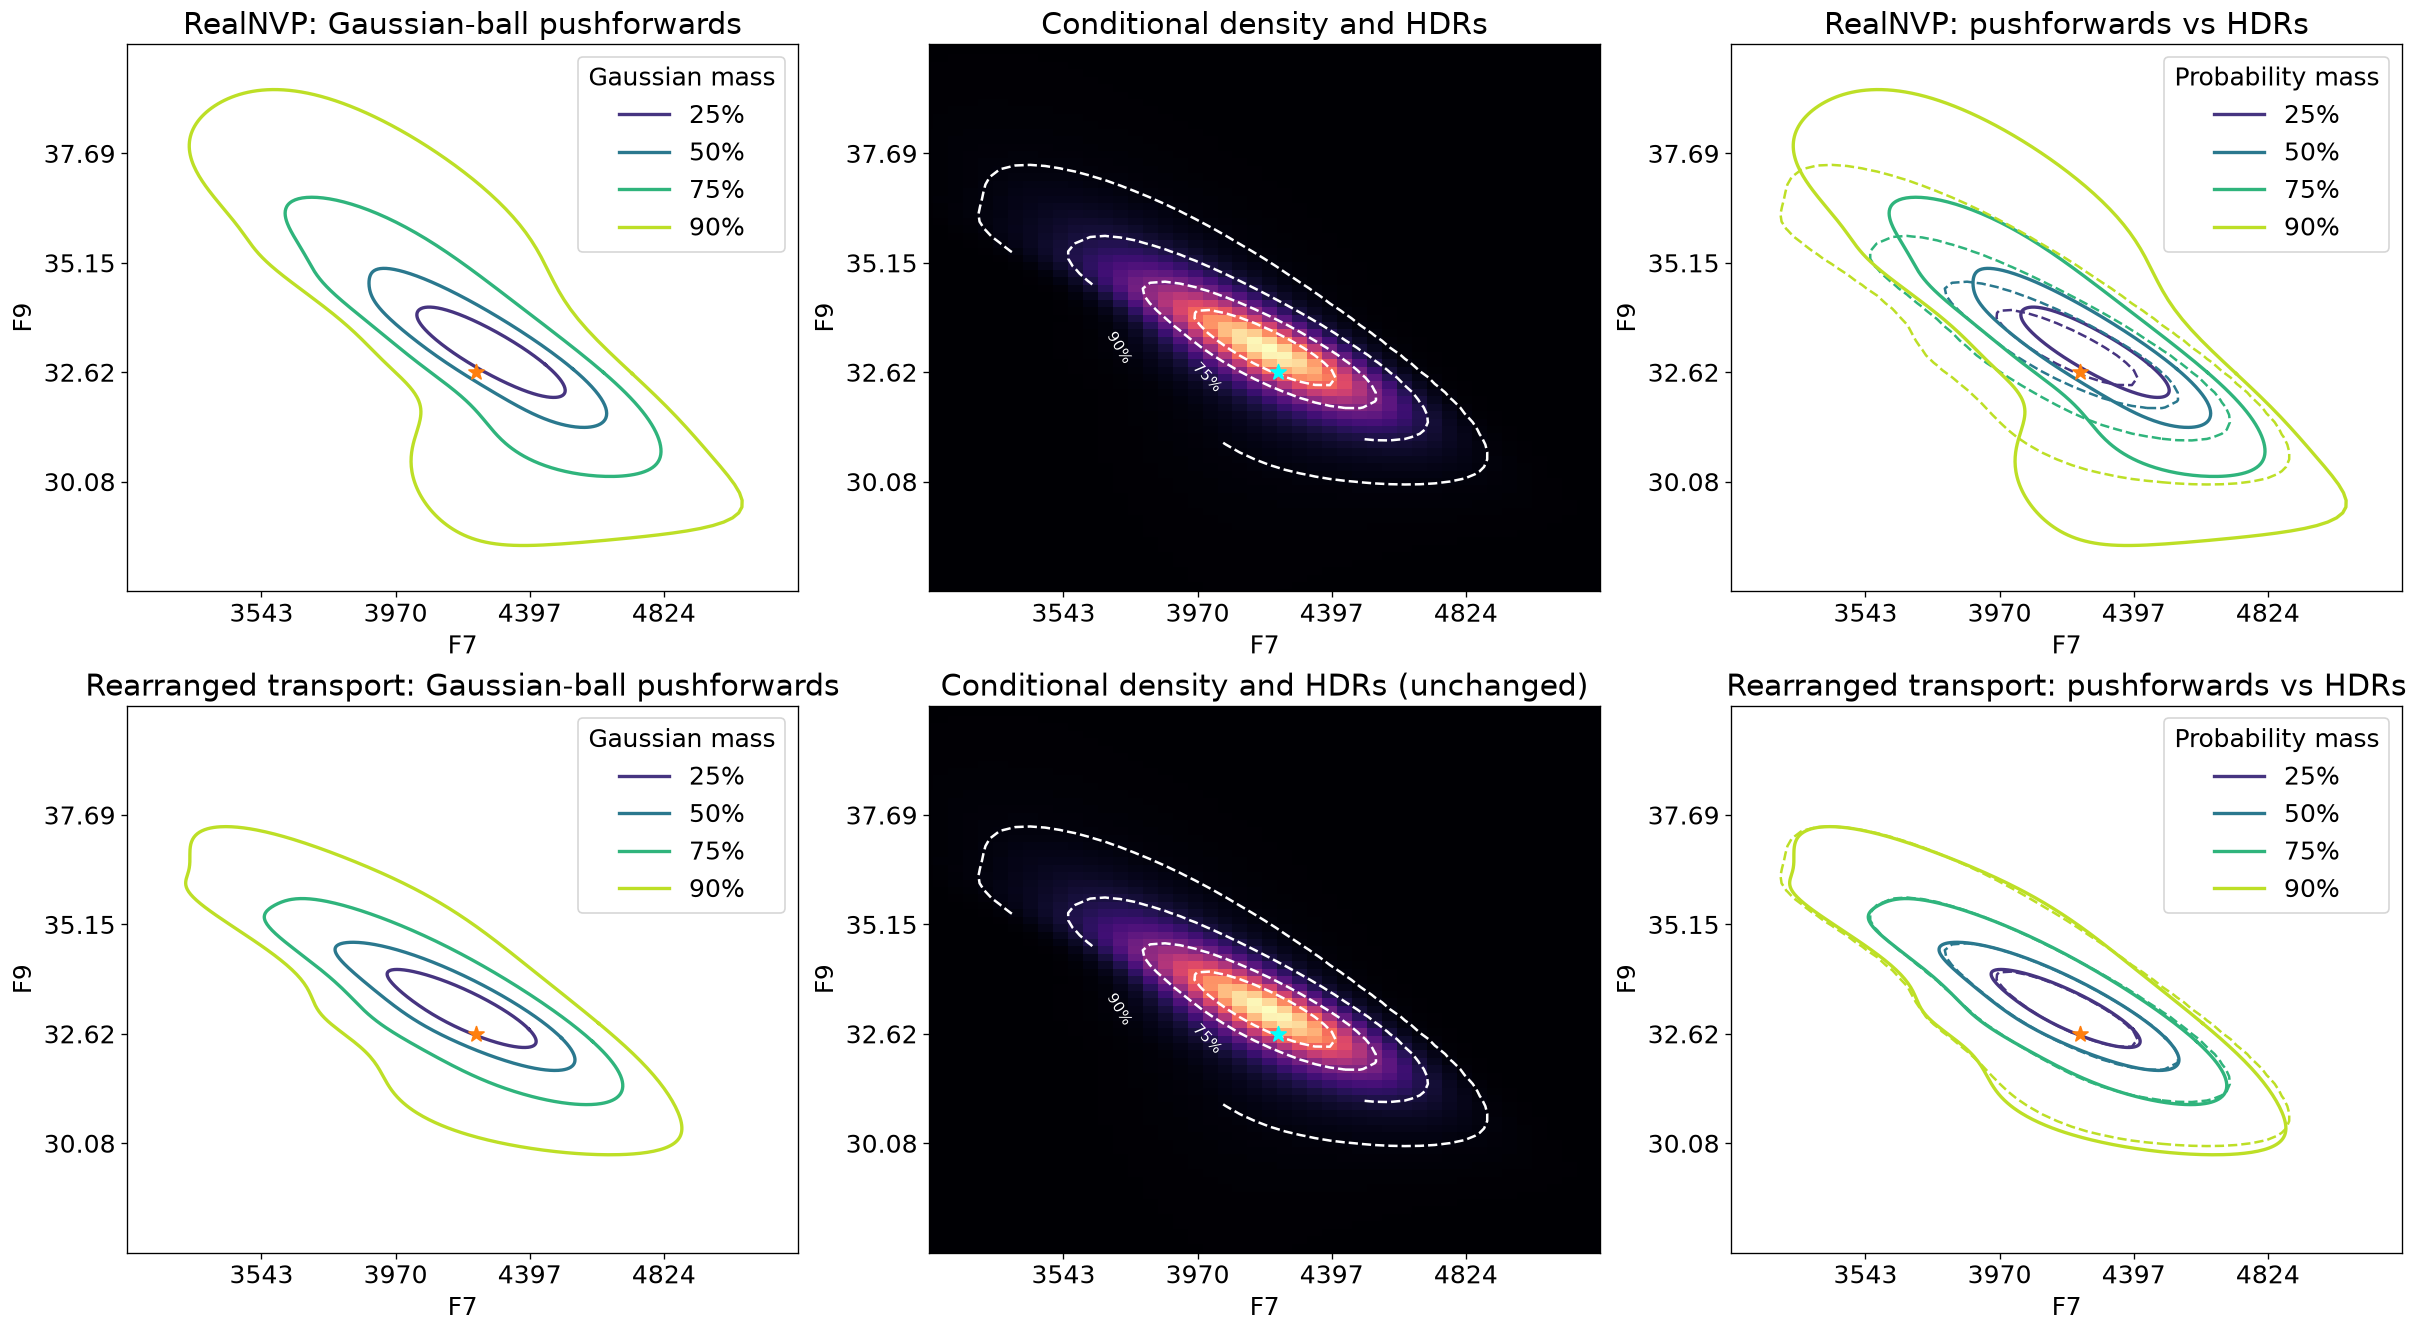

In [5]:
masses = (0.25, 0.50, 0.75, 0.90)
selected_index = int(rng.choice(len(test_data.x)))
selected_x = test_data.x[selected_index]
selected_y = test_data.y[selected_index].cpu().numpy()
contours = {
    mass: pushforward_contour(predictor, selected_x, mass)
    for mass in masses
}
rearranged_contours = {
    mass: pushforward_contour(rearranged_predictor, selected_x, mass)
    for mass in masses
}
integration_contour = pushforward_contour(predictor, selected_x, mass=0.999)
integration_lower, integration_upper = padded_bounds([integration_contour], padding=0.05)
f7_grid, f9_grid, density = density_grid(
    selected_x, integration_lower, integration_upper
)
thresholds = hdr_thresholds(density, f7_grid, f9_grid, masses)

hdr_90_mask = density >= thresholds[0.90]
hdr_90_points = np.column_stack((f7_grid[hdr_90_mask], f9_grid[hdr_90_mask]))
lower, upper = padded_bounds(
    [*contours.values(), *rearranged_contours.values(), hdr_90_points],
    padding=0.10,
)
colors = plt.cm.viridis(np.linspace(0.15, 0.9, len(masses)))

fig, axes = plt.subplots(2, 3, figsize=(20, 11), constrained_layout=True)
model_rows = (
    ("RealNVP", contours),
    ("Rearranged transport", rearranged_contours),
)

for row, (model_name, model_contours) in enumerate(model_rows):
    for mass, color in zip(masses, colors):
        contour = model_contours[mass]
        axes[row, 0].plot(
            contour[:, 0], contour[:, 1], color=color, linewidth=2, label=f"{mass:.0%}"
        )
    axes[row, 0].scatter(*selected_y, color="tab:orange", marker="*", s=90, zorder=3)
    axes[row, 0].set_title(f"{model_name}: Gaussian-ball pushforwards")
    axes[row, 0].legend(title="Gaussian mass")

    heatmap = axes[row, 1].pcolormesh(
        f7_grid, f9_grid, density, shading="auto", cmap="magma"
    )
    for mass in masses:
        hdr = axes[row, 1].contour(
            f7_grid,
            f9_grid,
            density,
            levels=[thresholds[mass]],
            colors="white",
            linestyles="--",
            linewidths=1.5,
        )
        axes[row, 1].clabel(
            hdr, fmt={thresholds[mass]: f"{mass:.0%}"}, fontsize=9
        )
    axes[row, 1].scatter(*selected_y, color="cyan", marker="*", s=90, zorder=3)
    density_title = "Conditional density and HDRs"
    if row == 1:
        density_title += " (unchanged)"
    axes[row, 1].set_title(density_title)

    for mass, color in zip(masses, colors):
        contour = model_contours[mass]
        axes[row, 2].plot(
            contour[:, 0],
            contour[:, 1],
            color=color,
            linewidth=2,
            label=f"{mass:.0%}",
        )
        axes[row, 2].contour(
            f7_grid,
            f9_grid,
            density,
            levels=[thresholds[mass]],
            colors=[color],
            linestyles="--",
            linewidths=1.5,
        )
    axes[row, 2].scatter(*selected_y, color="tab:orange", marker="*", s=90, zorder=3)
    axes[row, 2].set_title(f"{model_name}: pushforwards vs HDRs")
    axes[row, 2].legend(title="Probability mass")

for axis in axes.flat:
    axis.set_xlabel("F7")
    axis.set_ylabel("F9")
    axis.set_xlim(lower[0], upper[0])
    axis.set_ylim(lower[1], upper[1])
    axis.xaxis.set_major_locator(LinearLocator(6))
    axis.yaxis.set_major_locator(LinearLocator(6))
    for axis_ticks in (axis.xaxis.get_major_ticks(), axis.yaxis.get_major_ticks()):
        for edge_tick in (axis_ticks[0], axis_ticks[-1]):
            edge_tick.tick1line.set_visible(False)
            edge_tick.tick2line.set_visible(False)
            edge_tick.label1.set_visible(False)
            edge_tick.label2.set_visible(False)
            edge_tick.gridline.set_visible(False)

fig.savefig(
    REPOSITORY_ROOT / "figures/bio_realnvp_rearrangement.pdf",
    bbox_inches="tight",
)
plt.show()

## Conformalized 90% prediction regions

Both predictors are calibrated on the full calibration split at 90% coverage (10% significance) using the L2 norm of their pullback scores.

In [6]:
COVERAGE_MASS = 0.90
CALIBRATION_BATCH_SIZE = 512
VOLUME_MC_SAMPLES = 2_000
VOLUME_BATCH_SIZE = 1_024
VOLUME_SEED = 7

calibration_loader = make_xy_dataloader(
    dataset.get_splits().calibration,
    batch_size=CALIBRATION_BATCH_SIZE,
    shuffle=False,
)

conformal_config = TransportBasedConformalPredictorConfig(
    coverage_mass=COVERAGE_MASS,
    calibrator=NormCalibratorConfig(p=2.0),
    volume_mc_samples=VOLUME_MC_SAMPLES,
    volume_batch_size=VOLUME_BATCH_SIZE,
    volume_seed=VOLUME_SEED,
)

realnvp_conformal = TransportBasedConformalPredictor(
    predictor=predictor, config=conformal_config
).calibrate(calibration_loader)
rearranged_conformal = TransportBasedConformalPredictor(
    predictor=rearranged_predictor, config=conformal_config
).calibrate(calibration_loader)

In [7]:
volume_x = torch.cat((selected_x.unsqueeze(0), test_data.x[test_indices]), dim=0)
models = (
    ("RealNVP", realnvp_conformal),
    ("Rearranged transport", rearranged_conformal),
)

results = []
with torch.inference_mode():
    for name, conformal_predictor in models:
        log_volumes = conformal_predictor.estimate_log_volume(volume_x).cpu()
        results.append((
            name,
            float(conformal_predictor.threshold.cpu()),
            float(log_volumes[0]),
            float(log_volumes[1:].mean()),
            float(log_volumes[1:].std(unbiased=False)),
        ))

print("90% conformal regions (Monte Carlo log-volume in target space)")
print(f"{'Model':<24} {'Radius':>9} {'Selected x':>13} {'Mean of six':>13} {'Std of six':>12}")
for name, radius, selected_volume, mean_volume, std_volume in results:
    print(
        f"{name:<24} {radius:9.4f} {selected_volume:13.4f} "
        f"{mean_volume:13.4f} {std_volume:12.4f}"
    )

90% conformal regions (Monte Carlo log-volume in target space)
Model                       Radius    Selected x   Mean of six   Std of six
RealNVP                     2.0871        8.9385        9.0413       0.5079
Rearranged transport        2.1113        8.5588        8.8557       0.5018
